In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Load datasets
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Assign labels
fake["label"] = 0
true["label"] = 1

# Combine datasets
df = pd.concat([fake, true], axis=0).reset_index(drop=True)


In [3]:
!pip install wordcloud

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Load datasets
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Assign labels
fake["label"] = 0
true["label"] = 1

# Combine datasets
df = pd.concat([fake, true], axis=0).reset_index(drop=True)

In [5]:
print(df)

                                                   title  \
0       Donald Trump Sends Out Embarrassing New Year’...   
1       Drunk Bragging Trump Staffer Started Russian ...   
2       Sheriff David Clarke Becomes An Internet Joke...   
3       Trump Is So Obsessed He Even Has Obama’s Name...   
4       Pope Francis Just Called Out Donald Trump Dur...   
...                                                  ...   
44893  'Fully committed' NATO backs new U.S. approach...   
44894  LexisNexis withdrew two products from Chinese ...   
44895  Minsk cultural hub becomes haven from authorities   
44896  Vatican upbeat on possibility of Pope Francis ...   
44897  Indonesia to buy $1.14 billion worth of Russia...   

                                                    text    subject  \
0      Donald Trump just couldn t wish all Americans ...       News   
1      House Intelligence Committee Chairman Devin Nu...       News   
2      On Friday, it was revealed that former Milwauk...       New

In [7]:
print(df.info())  # Check data types and missing values
print(df["label"].value_counts())  # Count number of fake and real news
print(df.duplicated().sum())  # Check for duplicate entries


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None
label
0    23481
1    21417
Name: count, dtype: int64
209


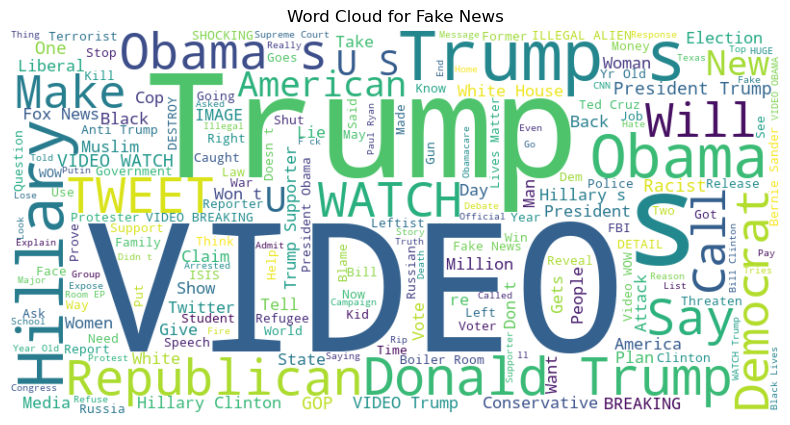

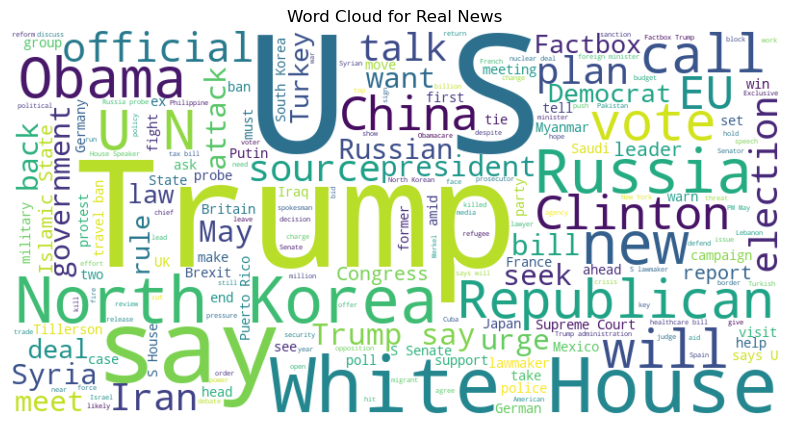

In [9]:
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

# Word cloud for fake news
generate_wordcloud(df[df["label"] == 0]["title"], "Word Cloud for Fake News")

# Word cloud for real news
generate_wordcloud(df[df["label"] == 1]["title"], "Word Cloud for Real News")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\heman\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
C:\Users\heman\AppData\Local\Temp\ipykernel_41460\4113788502.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette="viridis")


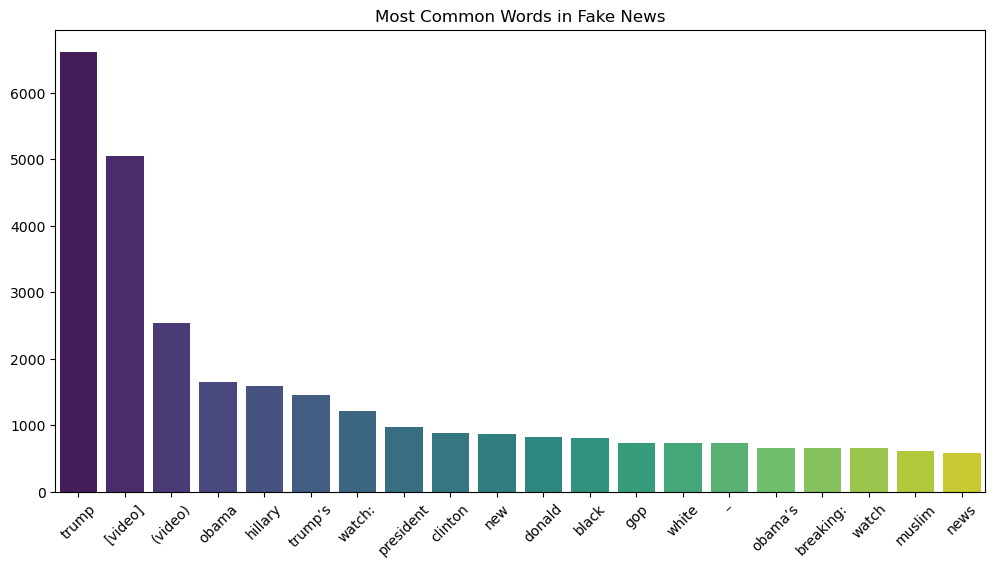

C:\Users\heman\AppData\Local\Temp\ipykernel_41460\4113788502.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette="viridis")


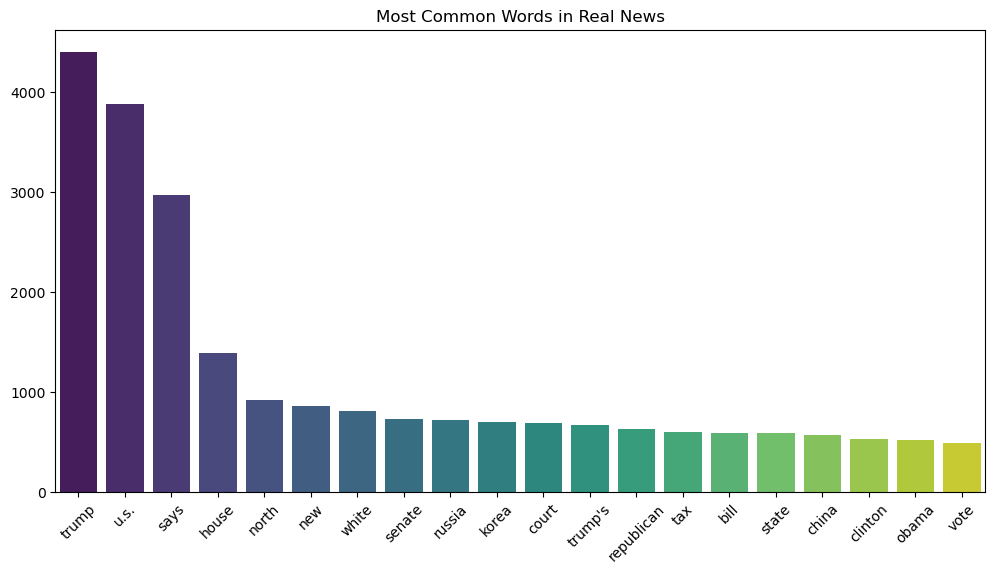

In [11]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def plot_word_freq(label, title):
    words = " ".join(df[df["label"] == label]["title"]).split()
    words = [word.lower() for word in words if word.lower() not in stop_words]
    
    common_words = Counter(words).most_common(20)
    words, counts = zip(*common_words)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(words), y=list(counts), palette="viridis")
    plt.xticks(rotation=45)
    plt.title(title)
    plt.show()

# Word frequency for fake news
plot_word_freq(0, "Most Common Words in Fake News")

# Word frequency for real news
plot_word_freq(1, "Most Common Words in Real News")


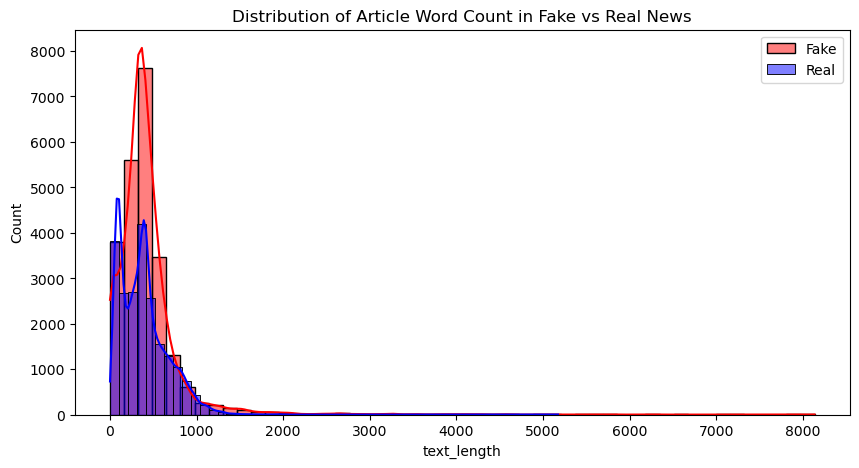

In [13]:
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df[df["label"] == 0]["text_length"], bins=50, color="red", label="Fake", kde=True)
sns.histplot(df[df["label"] == 1]["text_length"], bins=50, color="blue", label="Real", kde=True)
plt.legend()
plt.title("Distribution of Article Word Count in Fake vs Real News")
plt.show()


In [15]:
plt.savefig("eda_plots/fake_vs_real_word_count.png")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\heman\\eda_plots\\fake_vs_real_word_count.png'

<Figure size 640x480 with 0 Axes>

In [17]:
import os

# Create directory if it does not exist
os.makedirs("eda_plots", exist_ok=True)

# Now save the figure
plt.savefig("eda_plots/fake_vs_real_word_count.png")


<Figure size 640x480 with 0 Axes>

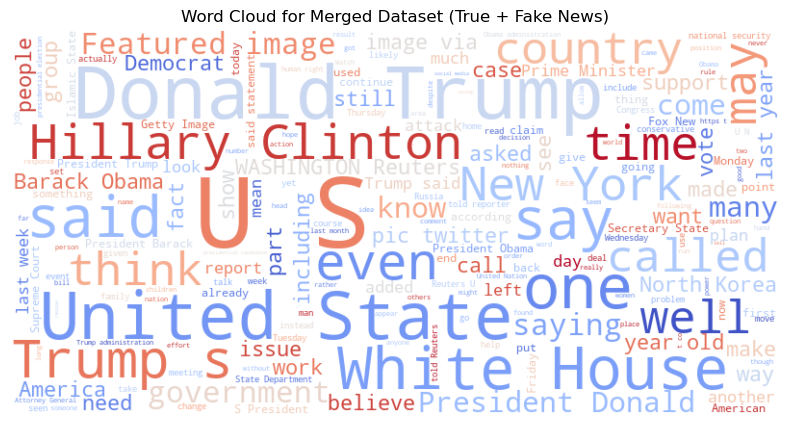

In [22]:


# Load datasets
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Combine datasets
fake["label"] = 0
true["label"] = 1
df = pd.concat([fake, true], axis=0).reset_index(drop=True)

# Combine all text into a single string
text = " ".join(df["text"].astype(str))

# Remove stopwords and punctuation
stop_words = set(stopwords.words('english'))
text = " ".join([word for word in text.split() if word.lower() not in stop_words and word not in string.punctuation])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="coolwarm").generate(text)

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Merged Dataset (True + Fake News)")
plt.show()


                                                   title  \
0       Donald Trump Sends Out Embarrassing New Year’...   
1       Drunk Bragging Trump Staffer Started Russian ...   
2       Sheriff David Clarke Becomes An Internet Joke...   
3       Trump Is So Obsessed He Even Has Obama’s Name...   
4       Pope Francis Just Called Out Donald Trump Dur...   
...                                                  ...   
44893  'Fully committed' NATO backs new U.S. approach...   
44894  LexisNexis withdrew two products from Chinese ...   
44895  Minsk cultural hub becomes haven from authorities   
44896  Vatican upbeat on possibility of Pope Francis ...   
44897  Indonesia to buy $1.14 billion worth of Russia...   

                                                    text    subject  \
0      Donald Trump just couldn t wish all Americans ...       News   
1      House Intelligence Committee Chairman Devin Nu...       News   
2      On Friday, it was revealed that former Milwauk...       New

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\heman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


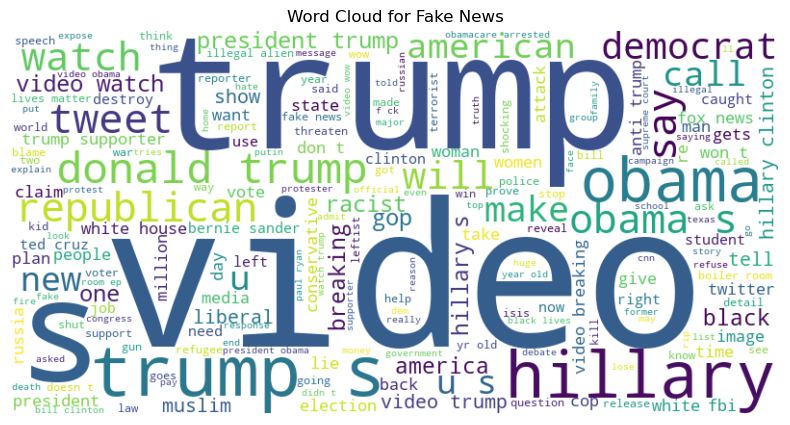

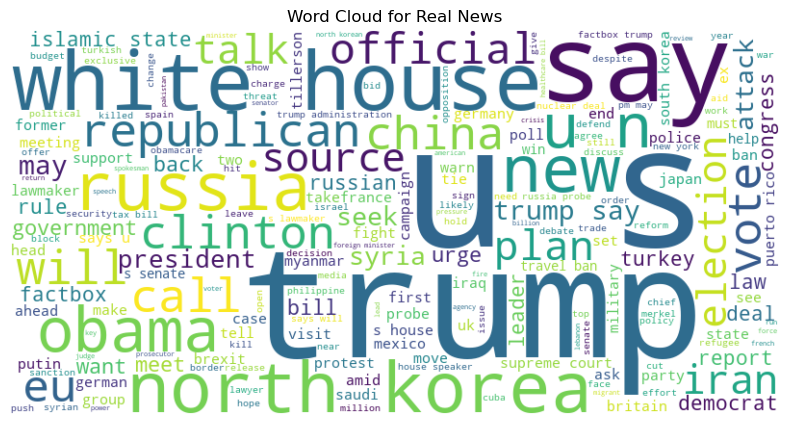

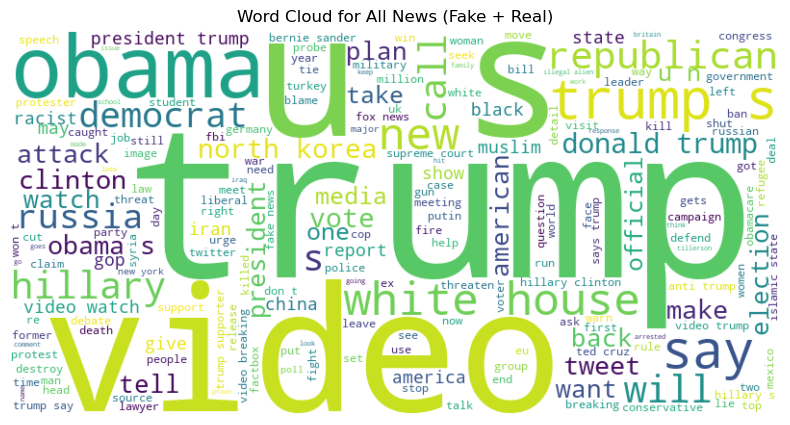

C:\Users\heman\AppData\Local\Temp\ipykernel_9612\1041078690.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette="viridis")


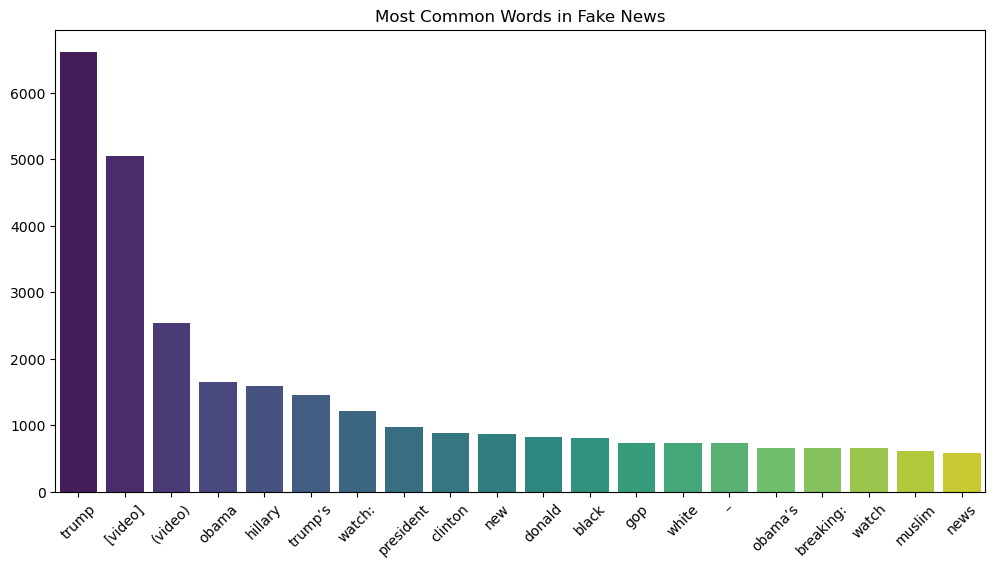

C:\Users\heman\AppData\Local\Temp\ipykernel_9612\1041078690.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette="viridis")


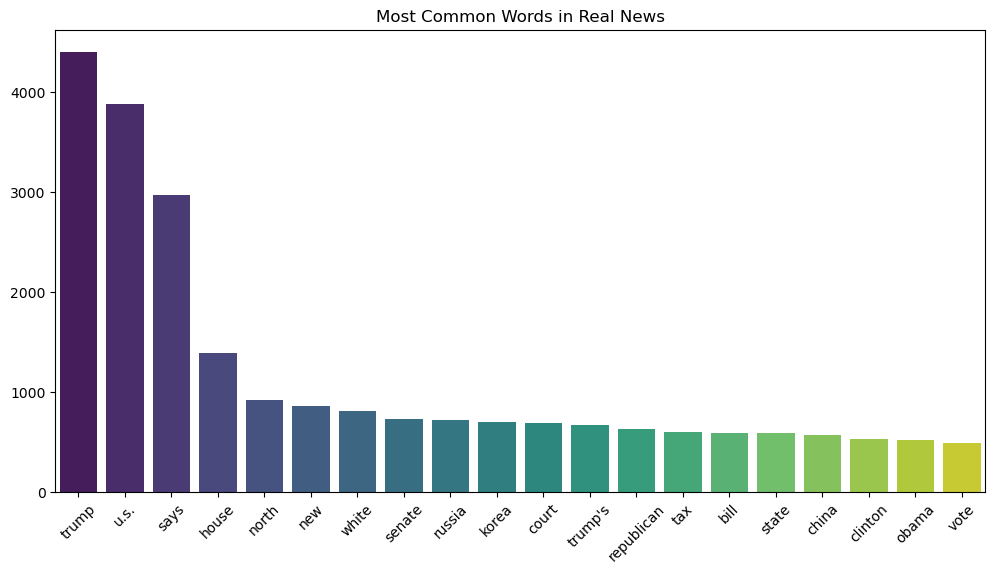

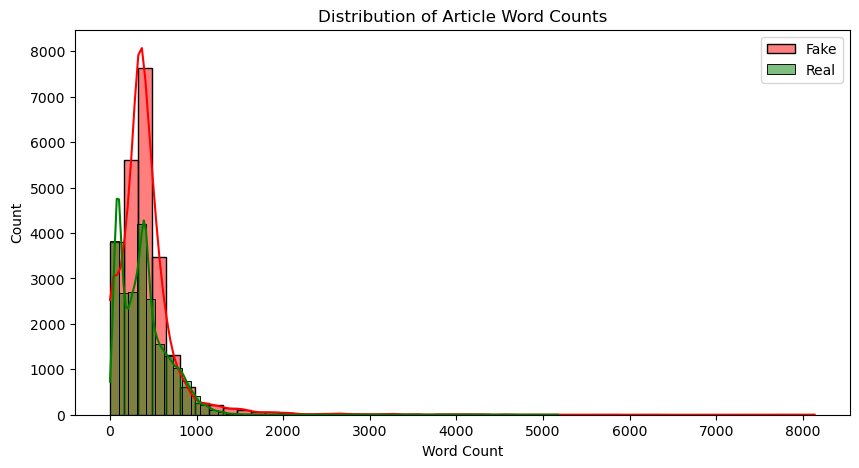

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Load datasets
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Assign labels
fake["label"] = 0
true["label"] = 1

# Combine datasets
df = pd.concat([fake, true], axis=0).reset_index(drop=True)

print(df)
print(df.info())  # Check data types and missing values
print(df["label"].value_counts())  # Count number of fake and real news
print(df.duplicated().sum())  # Check for duplicate entries

# Download stopwords
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Wordcloud Function (fixed case sensitivity)
def generate_wordcloud(text, title):
    text = " ".join(text).lower()  # Lowercase to avoid repetitions
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

# Word cloud for fake news
generate_wordcloud(df[df["label"] == 0]["title"], "Word Cloud for Fake News")

# Word cloud for real news
generate_wordcloud(df[df["label"] == 1]["title"], "Word Cloud for Real News")

# Word cloud for merged dataset
generate_wordcloud(df["title"], "Word Cloud for All News (Fake + Real)")

# Word Frequency Plot
def plot_word_freq(label, title):
    words = " ".join(df[df["label"] == label]["title"]).split()
    words = [word.lower() for word in words if word.lower() not in stop_words]
    
    common_words = Counter(words).most_common(20)
    words, counts = zip(*common_words)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(words), y=list(counts), palette="viridis")
    plt.xticks(rotation=45)
    plt.title(title)
    plt.show()

# Word frequency for fake news
plot_word_freq(0, "Most Common Words in Fake News")

# Word frequency for real news
plot_word_freq(1, "Most Common Words in Real News")

# Article Length Distribution
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df[df["label"] == 0]["text_length"], bins=50, color="red", label="Fake", kde=True)
sns.histplot(df[df["label"] == 1]["text_length"], bins=50, color="green", label="Real", kde=True)
plt.legend()
plt.title("Distribution of Article Word Counts")
plt.xlabel("Word Count")
plt.show()
